In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append('/app')
from database.db_connection import get_connection

conn = get_connection()
df = pd.read_sql("SELECT * FROM ml_features", conn)
conn.close()

print(f"Shape mới: {df.shape}")
print("--- THỐNG KÊ CHI TIẾT TỪNG FEATURE ---")

numeric_cols = ["lat", "lng", "area_m2", "price_vnd", "price_per_m2"]

bool_cols = [
    "has_wc", "has_ac", "has_parking", "has_kitchen", 
    "has_balcony", "has_security", "has_furniture", 
    "has_loft", "has_washer", "has_fridge", 
    "has_elevator", "has_basement", "free_hours", 
    "no_owner", "near_uni"
]

for col in numeric_cols + bool_cols:
    if col in df.columns:
        if col in bool_cols:
            count_ones = int(df[col].sum())
            print(f"  {col:20} : {count_ones} phòng có")
        else:
            valid_rows = df[col].count()
            print(f"  {col:20} : {valid_rows} / {len(df)} dòng hợp lệ")

Shape mới: (1190, 26)
--- THỐNG KÊ CHI TIẾT TỪNG FEATURE ---
  lat                  : 1190 / 1190 dòng hợp lệ
  lng                  : 1190 / 1190 dòng hợp lệ
  area_m2              : 1190 / 1190 dòng hợp lệ
  price_vnd            : 1190 / 1190 dòng hợp lệ
  price_per_m2         : 1190 / 1190 dòng hợp lệ
  has_wc               : 166 phòng có
  has_ac               : 854 phòng có
  has_parking          : 300 phòng có
  has_kitchen          : 31 phòng có
  has_balcony          : 211 phòng có
  has_security         : 342 phòng có
  has_furniture        : 777 phòng có
  has_loft             : 379 phòng có
  has_washer           : 746 phòng có
  has_fridge           : 594 phòng có
  has_elevator         : 405 phòng có
  has_basement         : 619 phòng có
  free_hours           : 946 phòng có
  no_owner             : 840 phòng có
  near_uni             : 246 phòng có


/tmp/ipykernel_189/1206943785.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM ml_features", conn)


In [2]:

df_clean = df.copy()

# Lọc giá và diện tích hợp lý
df_clean = df_clean[df_clean["price_vnd"].between(500_000, 20_000_000)]
df_clean = df_clean[df_clean["area_m2"].between(6, 80)]
df_clean = df_clean[df_clean["price_per_m2"].between(50_000, 500_000)]

# Bỏ cột không dùng
DROP_COLS = ["listing_id", "scraped_at", "posted_at_raw",
             "district_name", "price_per_m2", "room_type", "posted_at"]
df_clean = df_clean.drop(columns=[c for c in DROP_COLS if c in df_clean.columns])


df_clean["log_price"] = np.log1p(df_clean["price_vnd"])


print(f"Shape sau clean: {df_clean.shape}")
print(f"Null còn lại:\n{df_clean.isnull().sum()[df_clean.isnull().sum()>0]}")

Shape sau clean: (1071, 21)
Null còn lại:
Series([], dtype: int64)


Train: 856 | Test: 215


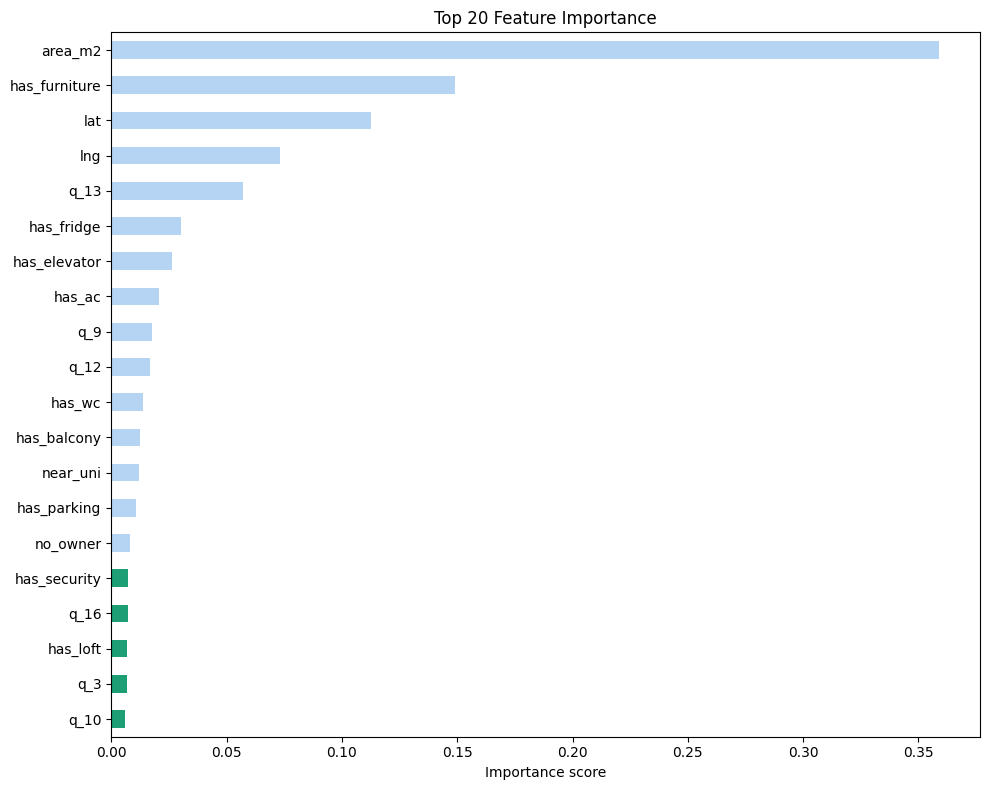


Feature mạnh (importance > 0.01): 14
  area_m2                   : 0.3588
  has_furniture             : 0.1489
  lat                       : 0.1125
  lng                       : 0.0730
  q_13                      : 0.0571
  has_fridge                : 0.0301
  has_elevator              : 0.0263
  has_ac                    : 0.0208
  q_9                       : 0.0178
  q_12                      : 0.0169
  has_wc                    : 0.0137
  has_balcony               : 0.0125
  near_uni                  : 0.0121
  has_parking               : 0.0106


In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# One-hot encode district_id
df_enc = pd.get_dummies(df_clean, columns=["district_id"], prefix="q", drop_first=True)

FEATURE_COLS = [c for c in df_enc.columns
                if c not in ["price_vnd", "log_price"]]

# Điền null lat/lng bằng trung vị (một số listing geocode thất bại)
for col in ["lat", "lng"]:
    df_enc[col] = df_enc[col].fillna(df_enc[col].median())

X = df_enc[FEATURE_COLS]
y = df_enc["log_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Train nhanh để xem feature importance
gb = GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)

# Vẽ top 20 feature quan trọng nhất
importance = pd.Series(gb.feature_importances_, index=FEATURE_COLS)
top20 = importance.nlargest(20).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#1D9E75" if i >= 15 else "#B5D4F4" for i in range(len(top20))]
top20.plot(kind="barh", ax=ax, color=colors[::-1])
ax.set_title("Top 20 Feature Importance")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("/app/data/feature_importance_v2.png", dpi=150)
plt.show()
print
# Chọn feature có importance > 0.01
STRONG_FEATURES = importance[importance > 0.01].index.tolist()
print(f"\nFeature mạnh (importance > 0.01): {len(STRONG_FEATURES)}")
for f in sorted(STRONG_FEATURES, key=lambda x: importance[x], reverse=True):
    print(f"  {f:25} : {importance[f]:.4f}")

In [4]:
all_features_sorted = importance.sort_values(ascending=False)

print(f"\n--- BẢNG XẾP HẠNG TOÀN BỘ {len(all_features_sorted)} FEATURES ---")
for f, val in all_features_sorted.items():
    # In ra với định dạng căn lề đẹp mắt
    print(f"  {f:25} : {val:.4f}")



--- BẢNG XẾP HẠNG TOÀN BỘ 39 FEATURES ---
  area_m2                   : 0.3588
  has_furniture             : 0.1489
  lat                       : 0.1125
  lng                       : 0.0730
  q_13                      : 0.0571
  has_fridge                : 0.0301
  has_elevator              : 0.0263
  has_ac                    : 0.0208
  q_9                       : 0.0178
  q_12                      : 0.0169
  has_wc                    : 0.0137
  has_balcony               : 0.0125
  near_uni                  : 0.0121
  has_parking               : 0.0106
  no_owner                  : 0.0082
  has_security              : 0.0071
  q_16                      : 0.0071
  has_loft                  : 0.0070
  q_3                       : 0.0067
  q_10                      : 0.0061
  q_11                      : 0.0060
  has_basement              : 0.0058
  free_hours                : 0.0051
  q_19                      : 0.0050
  q_5                       : 0.0041
  has_washer                : 0.

In [5]:

print(df[['district_id', 'district_name']].drop_duplicates().sort_values('district_id'))

     district_id district_name
92             1        Quận 1
11             2        Quận 2
1              3        Quận 3
211            4        Quận 4
108            5        Quận 5
59             6        Quận 6
36             7        Quận 7
31             8        Quận 8
9              9        Quận 9
32            10       Quận 10
97            11       Quận 11
4             12       Quận 12
7             13    Bình Thạnh
23            14      Bình Tân
42            15        Gò Vấp
69            16     Phú Nhuận
2             17      Tân Bình
0             18       Tân Phú
13            19       Thủ Đức
106           20    Bình Chánh
380           21       Hóc Môn
88            22        Nhà Bè
501           24        Củ Chi


In [7]:
import joblib, os

os.makedirs("/app/models", exist_ok=True)

# Dùng chỉ feature mạnh
X_train_final = X_train[STRONG_FEATURES]
X_test_final  = X_test[STRONG_FEATURES]

# Train model cuối
gb_final = GradientBoostingRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gb_final.fit(X_train_final, y_train)

from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

y_pred      = gb_final.predict(X_test_final)
y_pred_real = np.expm1(y_pred)
y_test_real = np.expm1(y_test)

r2   = r2_score(y_test_real, y_pred_real)
mae  = mean_absolute_error(y_test_real, y_pred_real)
rmse = np.sqrt(np.mean((y_pred_real - y_test_real)**2))

print(f"=== KẾT QUẢ MODEL V2 ===")
print(f"R²   : {r2:.4f}  ({r2*100:.1f}% variance explained)")
print(f"MAE  : {mae/1e6:.2f} triệu VNĐ")
print(f"RMSE : {rmse/1e6:.2f} triệu VNĐ")

# Lưu model và metadata
joblib.dump(gb_final,       "/app/models/best_model_v2.pkl")
joblib.dump(STRONG_FEATURES,"/app/models/feature_cols_v2.pkl")
joblib.dump({
    "r2": r2, "mae": mae, "rmse": rmse,
    "n_train": len(X_train_final),
    "n_test":  len(X_test_final),
    "n_features": len(STRONG_FEATURES),
}, "/app/models/model_metrics_v2.pkl")

print(f"\nĐã lưu model → /app/models/best_model_v2.pkl")
print(f"Sẵn sàng cho bước tiếp theo!")

=== KẾT QUẢ MODEL V2 ===
R²   : 0.4147  (41.5% variance explained)
MAE  : 0.69 triệu VNĐ
RMSE : 0.98 triệu VNĐ

Đã lưu model → /app/models/best_model_v2.pkl
Sẵn sàng cho bước tiếp theo!
